# **Projeto Análise de setor financeiro**

 ## *1. Importação de bibliotecas e leitura inicial dos dados*

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df_financas = pd.read_excel(r'C:\Users\Arthur\Desktop\AnáliseDadosFinanças\data\DadosFinanceiros.xlsx')
df_financas.head()

,Tipo,Componente,01/01/2019,01/02/2019,01/03/2019,01/04/2019,01/05/2019,01/06/2019,01/07/2019,01/08/2019,...,01/03/2022,01/04/2022,01/05/2022,01/06/2022,01/07/2022,01/08/2022,01/09/2022,01/10/2022,01/11/2022,01/12/2022
0,Receitas,Vendas,"30000,00","32456,90","33128,34","33560,00","33890,76","34200,00","34300,00","34500,00",...,"43000,00","43000,00","43000,00","43000,00","43000,00","43000,00","43000,00","43000,00","51500,00","51500,00"
1,Receitas,Aluguéis,"1000,00","1234,00","1267,00","1267,00","1267,00","1300,00","1340,00","1500,00",...,"4000,00","4000,00","4000,00","4000,00","6000,00","6000,00","6000,00","6000,00","6000,00","6000,00"
2,Receitas,Licenciamento,"5000,00","5000,00","5000,00","5000,00","5000,00","5000,00","5000,00","5000,00",...,"7000,00","7000,00","7000,00","7000,00","7000,00","7000,00","7000,00","7000,00","8000,00","8000,00"
3,Receitas,Franquias,"2000,00","2000,00","2000,00","2000,00","2000,00","2000,00","2000,00","2100,00",...,"1400,00","1400,00","2000,00","2000,00","1000,00","1000,00","1000,00","1000,00","2000,00","1000,00"
4,Receitas,Investimentos,"2000,00","2000,00","2000,00","2000,00","2000,00","2000,00","2000,00","2000,00",...,"2500,00","2500,00","2500,00","2000,00","2000,00","2000,00","2000,00","2000,00","2500,00","2500,00"


In [4]:
df_financas.shape

(12, 38)

- #### OBS: Tabela de dados precisa de ajustes. Muitos problemas no layout inicial.

## *2. Limpeza e Tratamento de Dados*

In [5]:
colunas_data = df_financas.columns.drop(['Tipo', 'Componente'])

df_new_table = df_financas.melt(
    id_vars=['Tipo', 'Componente'],
    value_vars=colunas_data,
    var_name='Data',
    value_name='Valor'
)

df_new_table['Valor'] =(
    df_new_table['Valor']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)

)

df_new_table.head()

,Tipo,Componente,Data,Valor
0,Receitas,Vendas,01/01/2019,30000.0
1,Receitas,Aluguéis,01/01/2019,1000.0
2,Receitas,Licenciamento,01/01/2019,5000.0
3,Receitas,Franquias,01/01/2019,2000.0
4,Receitas,Investimentos,01/01/2019,2000.0


In [6]:
df_new_table['Data'] = pd.to_datetime(df_new_table['Data'], format='%d/%m/%Y')
df_new_table['Ano'] = df_new_table['Data'].dt.year
df_new_table.head()

,Tipo,Componente,Data,Valor,Ano
0,Receitas,Vendas,2019-01-01,30000.0,2019
1,Receitas,Aluguéis,2019-01-01,1000.0,2019
2,Receitas,Licenciamento,2019-01-01,5000.0,2019
3,Receitas,Franquias,2019-01-01,2000.0,2019
4,Receitas,Investimentos,2019-01-01,2000.0,2019


## *3. Análise Exploratória dos Dados (EDA)*

In [7]:
df_new_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 432 entries, 0 to 431
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tipo        432 non-null    object        
 1   Componente  432 non-null    object        
 2   Data        432 non-null    datetime64[ns]
 3   Valor       432 non-null    float64       
 4   Ano         432 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(2)
memory usage: 15.3+ KB


In [8]:
df_new_table.describe()

,Data,Valor,Ano
count,432,432.000000,432.000000
mean,2020-10-15 18:40:00,7113.439815,2020.333333
min,2019-01-01 00:00:00,-1300.000000,2019.000000
25%,2019-09-23 12:00:00,1500.000000,2019.000000
50%,2020-06-16 00:00:00,3000.000000,2020.000000
75%,2022-03-08 18:00:00,7000.000000,2022.000000
max,2022-12-01 00:00:00,51500.000000,2022.000000
std,NaN,10071.060810,1.248665


- ### *Distribuição do valor por tipo*

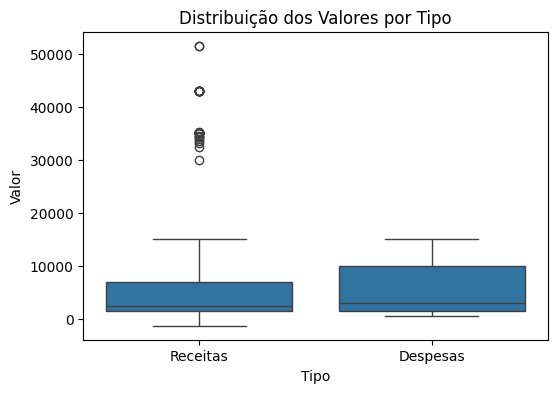

In [9]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_new_table, x='Tipo', y='Valor')
plt.title('Distribuição dos Valores por Tipo')
plt.show()

- ### *Tendência temporal geral*

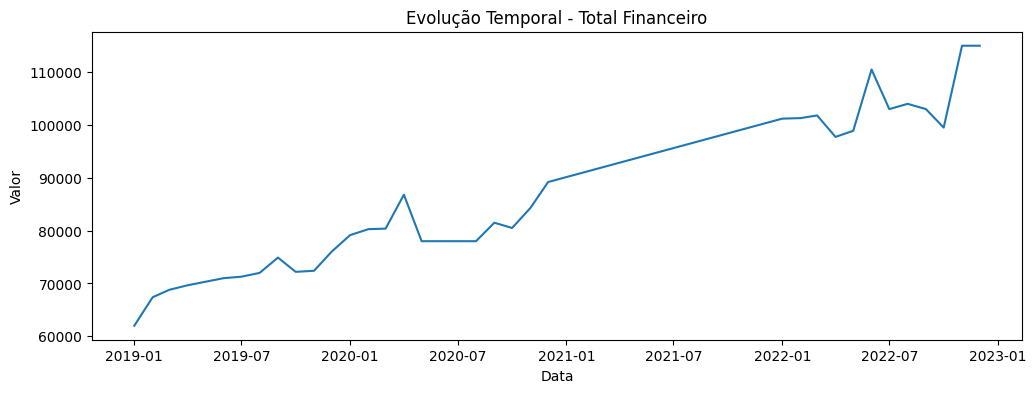

In [10]:
df_ts = df_new_table.groupby('Data')['Valor'].sum()

plt.figure(figsize=(12,4))
plt.plot(df_ts)
plt.title('Evolução Temporal - Total Financeiro')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.show()

## *4. Cálculo dos KPIs*

- ### l *Total de Receitas*

In [11]:
total_receitas = df_new_table[df_new_table['Tipo'] == 'Receitas']['Valor'].sum()
total_receitas

np.float64(1920089.0)

- #### Conclusão: **1.92** milhões de receita no total.
    - Valor consistente e suficiente para bancar as despesas totais e ainda gerar margem positiva sem comprometer a saúde do fluxo financeiro.

- ### ll *Total de Despesas*

In [13]:
total_despesas = df_new_table[df_new_table['Tipo'] == 'Despesas']['Valor'].sum()
total_despesas

np.float64(1152917.0)

- #### Conclusão: 1.15 milhões de despesas no total.
    - Valor bem abaixo em relação à receita total gerada. 
    - Mostra que os gastos estão bem controlados.
    - Estrutura de custos relativamente bem distribuída, apesar de pontos críticos que merecem análise mais detalhada.

- ### lll *Margem de Lucro*

In [15]:
margem_lucro = (total_receitas - total_despesas) / total_receitas
margem_lucro

np.float64(0.39955022918208477)

- #### Conclusão: 39,96% de margem de lucro
    - Bastante saudável para a maioria dos setores.
    - Indica estabilidade e capacidade de investimento.

- ### lV *Total de Receitas por Componente* 

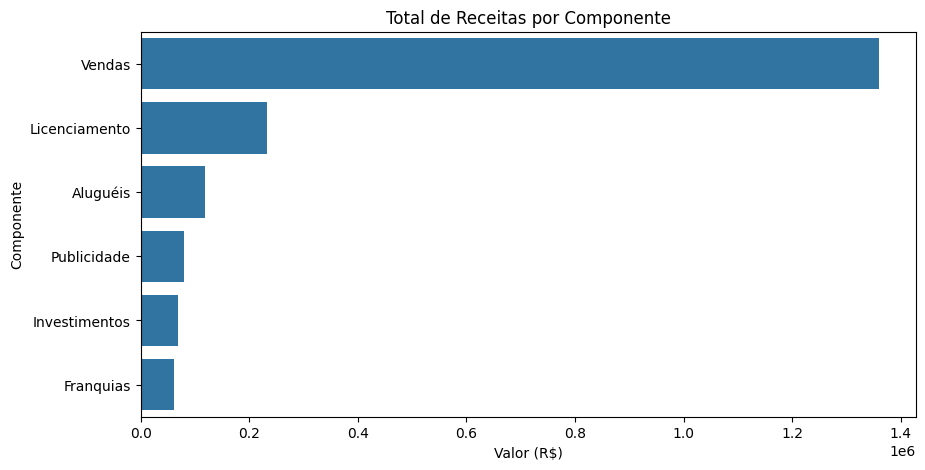

In [26]:
receitas = df_new_table[df_new_table['Tipo'] == 'Receitas']

receitas_componente = (
    receitas.groupby('Componente')['Valor']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=receitas_componente.values, y=receitas_componente.index, orient='h')
plt.title('Total de Receitas por Componente')
plt.xlabel('Valor (R$)')
plt.ylabel('Componente')
plt.show()

- #### Conclusão: Maior parte da concentração de receitas em **Vendas**
    - Discrepância notável mostra que demais componentes merecem mais atenção estratégica e reavaliação para reposicionamento, reformulação ou descontinuidade.

- ### V *Total de Despesas por Componente em relação à média de Despesas*

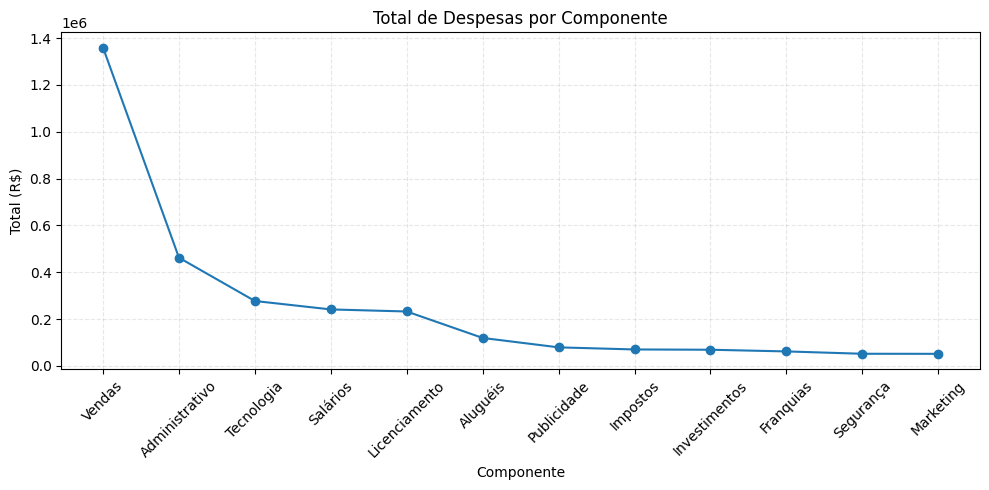

In [28]:
total_despesas = df_new_table.groupby('Componente')['Valor'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.plot(total_despesas.index, total_despesas.values, marker='o')
plt.title('Total de Despesas por Componente')
plt.xlabel('Componente')
plt.ylabel('Total (R$)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- #### Conclusão: Despesas concentradas em áreas essenciais da operação
    - Ajustes em Tecnologias e Salários devem ser avaliados, visando aumento de eficiência e corte de gastos

- ### VI *Receitas e despesas por componente e ano*

In [27]:
ano = (df_new_table.groupby(['Tipo', 'Componente', 'Ano'])['Valor'].sum().reset_index())
ano  

,Tipo,Componente,Ano,Valor
0,Despesas,Administrativo,2019,132000.0
1,Despesas,Administrativo,2020,150000.0
2,Despesas,Administrativo,2022,180000.0
3,Despesas,Impostos,2019,12000.0
4,Despesas,Impostos,2020,21000.0
5,Despesas,Impostos,2022,37000.0
6,Despesas,Marketing,2019,16500.0
7,Despesas,Marketing,2020,16317.0
8,Despesas,Marketing,2022,18500.0
9,Despesas,Salários,2019,40000.0


- #### Conclusão: Maiores valores financeiros presentes nos segmentos superiores, tanto receitas quanto despesas.
    - Exigência de monitoramento contínuo, pois existe risco e ao mesmo tempo oportunidade. 

- ### *Principais segmentos da empresa*

In [38]:
df_new_table['Segmento'] = pd.qcut(df_new_table['Valor'], q=6, labels=['Seg1', 'Seg2', 'Seg3', 'Seg4', 'Seg5', 'Seg6'])

In [39]:
df_segmentos = df_new_table.groupby('Segmento')['Valor'].agg(['mean', 'sum', 'count'])
df_segmentos

C:\Users\Arthur\AppData\Local\Temp\ipykernel_21872\4081363984.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_segmentos = df_new_table.groupby('Segmento')['Valor'].agg(['mean', 'sum', 'count'])


,mean,sum,count
Segmento,,,
Seg1,833.583333,60018.0,72
Seg2,1678.141593,189630.0,113
Seg3,2652.426190,111401.9,42
Seg4,4974.922222,313420.1,63
Seg5,8194.520548,598200.0,73
Seg6,26091.826087,1800336.0,69


In [40]:
receitas_seg = df_new_table[df_new_table['Tipo'] == 'Receitas'].groupby('Segmento')['Valor'].sum()

despesas_seg = df_new_table[df_new_table['Tipo'] == 'Despesas'].groupby('Segmento')['Valor'].sum()

C:\Users\Arthur\AppData\Local\Temp\ipykernel_21872\3298381052.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  receitas_seg = df_new_table[df_new_table['Tipo'] == 'Receitas'].groupby('Segmento')['Valor'].sum()
C:\Users\Arthur\AppData\Local\Temp\ipykernel_21872\3298381052.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  despesas_seg = df_new_table[df_new_table['Tipo'] == 'Despesas'].groupby('Segmento')['Valor'].sum()


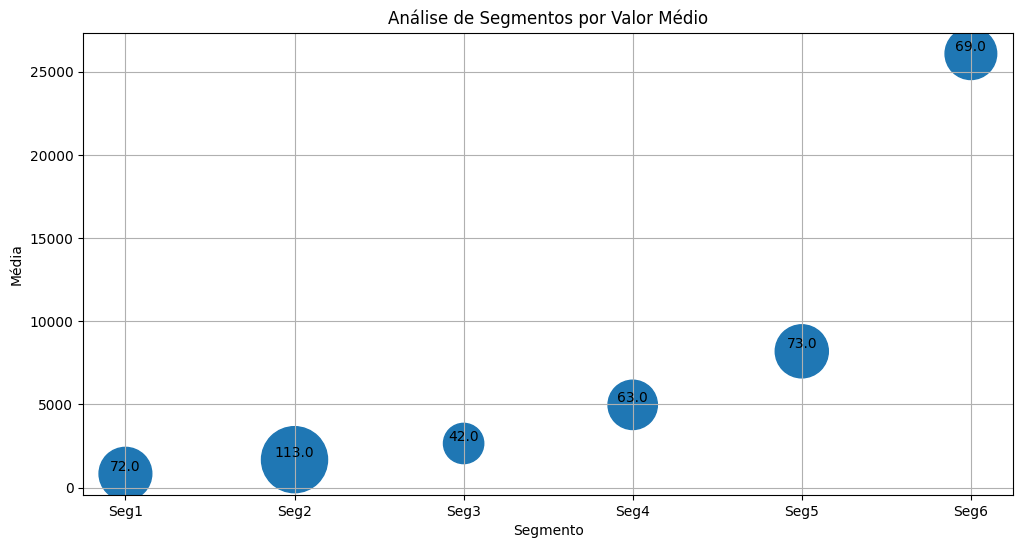

In [41]:
segmento_maior_receita = receitas_seg.idxmax()
segmento_menor_receita = despesas_seg.idxmin()

segmento_maior_despesa = despesas_seg.idxmax()
segmento_menor_despesa = despesas_seg.idxmin()

plt.figure(figsize=(12,6))
plt.scatter(df_segmentos.index,df_segmentos['mean'], s=df_segmentos['count']*20,)
for i, v in df_segmentos.iterrows():
    plt.text(i, v['mean'], f'{v["count"]}', ha='center', va='bottom')

plt.title('Análise de Segmentos por Valor Médio')
plt.xlabel('Segmento')
plt.ylabel('Média')
plt.grid(True)
plt.show()

## 5. *Visualizações*

- ### *Total de receitas vs despesas por ano*

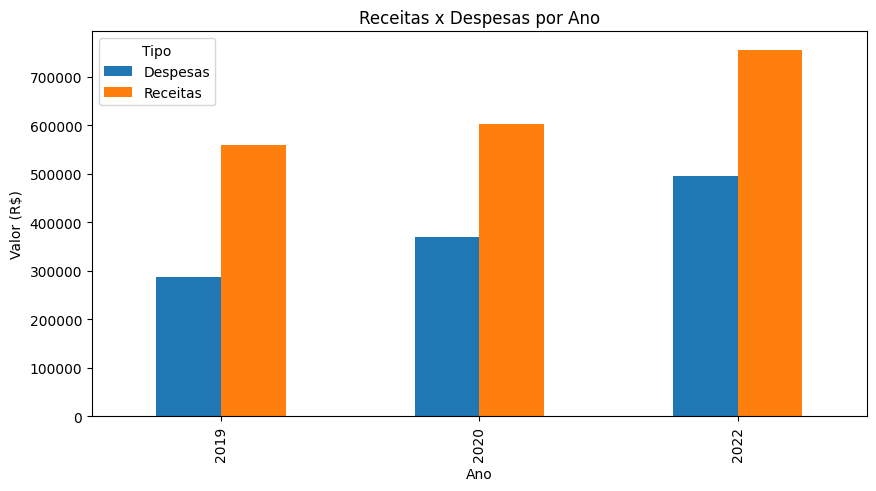

In [56]:
pivot_ano = df_new_table.pivot_table(
    index='Ano',
    columns='Tipo',
    values='Valor',
    aggfunc='sum'
)

pivot_ano.plot(kind='bar', figsize=(10, 5))
plt.title('Receitas x Despesas por Ano')
plt.ylabel('Valor (R$)')
plt.show()

#### - A empresa da análise em questão apresenta um cenário financeiro com excelente relação entre receitas e despesas e eficiência operacional, resultando em uma margem de lucro satisfatória.
